# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [1]:
import logging
import sys

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

log_file = logging.FileHandler('recommendations.log', mode='w')
log_file.setFormatter(logging.Formatter('%(asctime)s %(levelname)s %(message)s'))

console_out = logging.StreamHandler(sys.stdout)
console_out.setFormatter(logging.Formatter('%(message)s'))

logging.basicConfig(handlers=(log_file, console_out), level=logging.INFO)

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
%config InlineBackend.figure_format = 'retina'

# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [3]:
tracks = pd.read_parquet('data/tracks.parquet')
catalog_names = pd.read_parquet('data/catalog_names.parquet')
interactions = pd.read_parquet('data/interactions.parquet')

In [4]:
# Для удобства переименуем колонки
tracks.rename(columns={
    'albums': 'album',
    'genres': 'genre',
    'artists': 'artist'}, inplace=True)

# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

tracks

In [ ]:
tracks.sample(8).T

,247314,820704,340290,601392,677393,743730,878850,44259
track_id,15301994,64802240,22065561,41747210,49204013,56170821,72291226,369811
album,[1671190],[10435452],[2541265],[5486012],[6736993],"[8291973, 11549216]","[12417723, 12566732]",[37473]
artist,[188964],[22766],"[3100809, 3490184]",[649526],[3121],"[586040, 712921]",[4772494],[48247]
genre,"[2, 102]",[70],"[3, 75]",[68],"[47, 157]",[68],"[3, 75]","[47, 159]"


In [6]:
tracks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   track_id  1000000 non-null  int64 
 1   album     1000000 non-null  object
 2   artist    1000000 non-null  object
 3   genre     1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB


In [ ]:
print('Описательная статистика')
tracks.describe().T

Описательная статистика


,count,mean,std,min,25%,50%,75%,max
track_id,1000000.0,3.685121e+07,2.679771e+07,26.0,15430882.75,34550465.5,56925570.75,101521819.0


In [8]:
print('Незаполненные значения')
pd.DataFrame(tracks.isnull().sum()).T

Незаполненные значения


,track_id,album,artist,genre
0,0,0,0,0


In [9]:
# Проверим заполненность имён
tracks_ids = set(tracks['track_id'].unique())
tracks_names = set(catalog_names.query('type == "track"')['id'].unique())
logging.info(f'Количество "track" без имени: {len(tracks_ids - tracks_names)}')

def count_nameless_prop(prop: str):
    '''Рассчитывает количество безымянных значений свойства "prop"'''
    ids_count = set(tracks[[prop]].explode(prop, ignore_index=True)[prop].unique())
    names_count = set(catalog_names.query('type == @prop')['id'].unique())
    logging.info(f'Количество "{prop}" без имени: {len(ids_count - names_count)}')

count_nameless_prop('album')
count_nameless_prop('genre')
count_nameless_prop('artist')

Количество "track" без имени: 0
Количество "album" без имени: 1
Количество "genre" без имени: 31
Количество "artist" без имени: 1


In [10]:
def max_len_prop(prop: str):
    '''Рассчитывает максимальную длину свойства "prop"'''
    max_len = tracks[['track_id', prop]].explode(prop) \
        .groupby(['track_id']).agg(len=(prop, 'count')).reset_index()['len'].max()
    
    logging.info(f'Максимальная длина свойства "{prop}": {max_len}')

max_len_prop('album')
max_len_prop('genre')
max_len_prop('artist')

Максимальная длина свойства "album": 2844
Максимальная длина свойства "genre": 10
Максимальная длина свойства "artist": 26


In [11]:
# Вычислим количество дубликатов для свойства
def duplicate_count_prop(prop: str):
    '''Рассчитывает количество дубликатов свойства "prop"'''
    duplicate_count = tracks.explode(prop)[['track_id', prop]] \
        .merge(catalog_names.query('type == @prop'), left_on=prop, right_on='id')[['track_id', 'name', 'id']] \
        .groupby(['track_id', 'name']).agg(count=('id', 'count')).reset_index() \
        .query('count > 1') \
        ['name'].nunique()
        
    logging.info(f'Количество дубликатов свойства "{prop}": {duplicate_count}')
        
duplicate_count_prop('album')
duplicate_count_prop('genre')
duplicate_count_prop('artist')         

Количество дубликатов свойства "album": 47868
Количество дубликатов свойства "genre": 0
Количество дубликатов свойства "artist": 43


catalog_names

In [ ]:
catalog_names.sample(8).T

,99305,273124,754959,1013218,182517,1800592,1511397,1426756
id,1238009,4371735,4693342,7308487,2904540,95484773,51491973,42805858
type,album,album,artist,track,album,track,track,track
name,Nostalgic for the Future,"Самый русский хит!, Vol. 1",Yaşlı Amca,Lost And Late,Bikini Body Workout,Останься,Silence,3:32


In [13]:
catalog_names.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812471 entries, 0 to 1812470
Data columns (total 3 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   id      int64 
 1   type    object
 2   name    object
dtypes: int64(1), object(2)
memory usage: 41.5+ MB


In [ ]:
print('Описательная статистика')
catalog_names.describe().T

Описательная статистика


,count,mean,std,min,25%,50%,75%,max
id,1812471.0,2.321647e+07,2.526044e+07,0.0,3480524.0,12114360.0,37738170.0,101521819.0


In [15]:
print('Незаполненные значения')
pd.DataFrame(catalog_names.isnull().sum()).T

Незаполненные значения


,id,type,name
0,0,0,0


In [16]:
print('Уникальные значения свойства "type"')
pd.DataFrame(catalog_names["type"].value_counts()).T

Уникальные значения свойства "type"


type,track,album,artist,genre
count,1000000,658724,153581,166


interactions

In [17]:
interactions.sample(8).T

,144,129,58,1190,87,448,909,1415
user_id,736786,1221992,781483,1258853,156288,285388,661841,185501
track_id,21101461,62554717,40038187,34972339,53275013,47220131,55116965,39540234
track_seq,145,130,59,1191,88,449,910,1416
started_at,2022-05-23 00:00:00,2022-09-01 00:00:00,2022-03-18 00:00:00,2022-08-06 00:00:00,2022-10-27 00:00:00,2022-07-27 00:00:00,2022-09-13 00:00:00,2022-07-01 00:00:00


In [18]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.4 GB


In [19]:
print('Описательная статистика')
interactions.describe().T

Описательная статистика


,count,mean,min,25%,50%,75%,max,std
user_id,222629898.0,687576.660624,0.0,343371.0,687973.0,1031127.0,1374582.0,396903.293288
track_id,222629898.0,36536224.961649,26.0,14808489.0,35524737.0,56511373.0,101521819.0,26617816.837147
track_seq,222629898.0,462.140293,1.0,56.0,181.0,506.0,16637.0,825.731213
started_at,222629898,2022-08-29 16:39:44.541336320,2022-01-01 00:00:00,2022-07-02 00:00:00,2022-09-15 00:00:00,2022-11-09 00:00:00,2022-12-31 00:00:00,NaN


In [20]:
print('Незаполненные значения')    
pd.DataFrame(interactions.isnull().sum()).T

Незаполненные значения


,user_id,track_id,track_seq,started_at
0,0,0,0,0


In [21]:
logging.info(f'Количество уникальных пользователей:{interactions["user_id"].nunique()}')

Количество уникальных пользователей:1373221


# Выводы

Приведём выводы по первому знакомству с данными:
- Количество "track" без имени: 0
- Количество "album" без имени: 1
- Количество "genre" без имени: 31
- Количество "artist" без имени: 1
- Максимальная длина свойства "album": 2844
- Максимальная длина свойства "genre": 10
- Максимальная длина свойства "artist": 26
- Количество дубликатов свойства "album": 47868
- Количество дубликатов свойства "genre": 0
- Количество дубликатов свойства "artist": 43

Коррекирующие действия выполнены ниже

# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

<Axes: xlabel='started_at'>

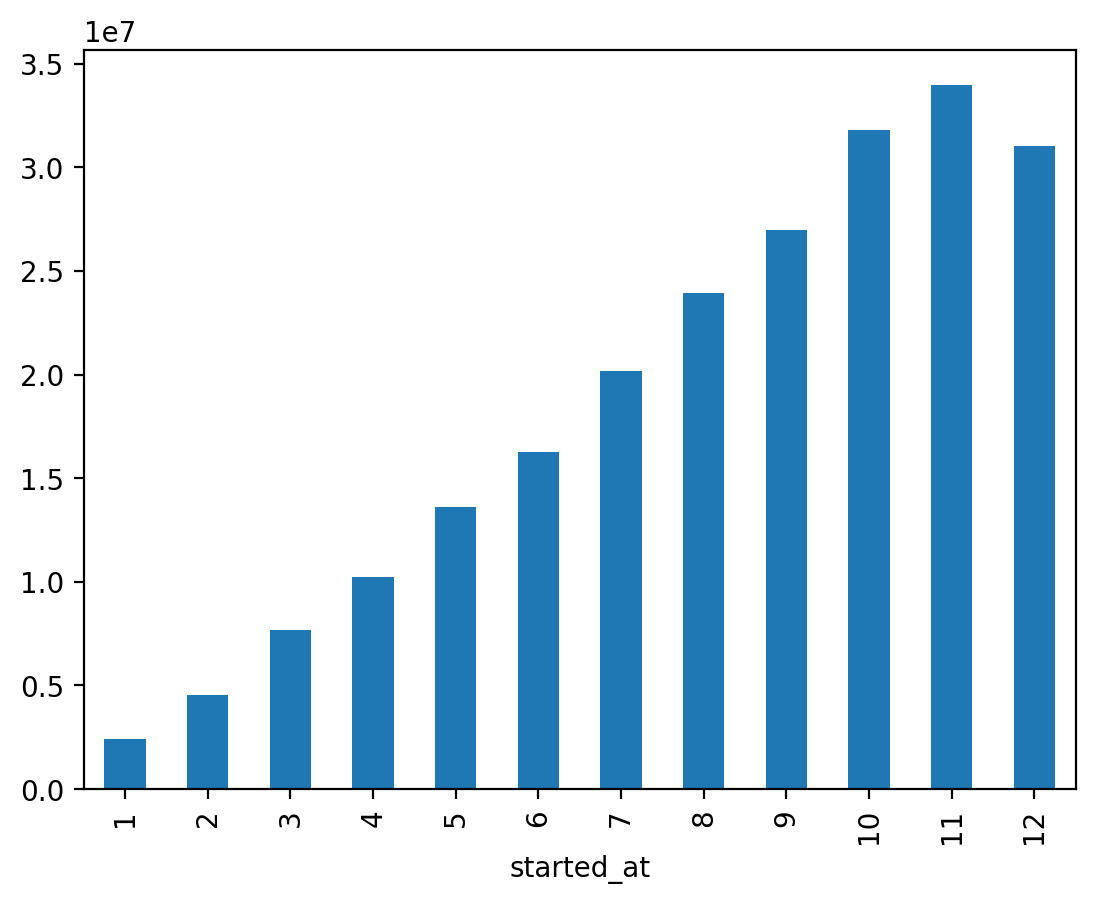

In [22]:
interactions['started_at'].dt.month.value_counts().sort_index().plot(kind='bar')

Наиболее популярные треки

In [23]:
interactions.groupby('track_id').agg(votes=('user_id', 'count')).reset_index() \
    .sort_values('votes', ascending=False).head(10) \
    .merge(catalog_names.query('type == "track"'), left_on='track_id', right_on='id', how='left')[['name', 'votes']] \
    .set_index([pd.Index(range(1, 11))])

,name,votes
1,Smells Like Teen Spirit,111062
2,Believer,106921
3,Numb,101924
4,I Got Love,99490
5,Юность,86670
6,Way Down We Go,86246
7,Shape of You,85886
8,In The End,85244
9,Shape Of My Heart,85042
10,Life,84748


Наиболее популярные жанры

In [24]:
interactions.groupby('track_id').agg(votes=('user_id', 'count')).reset_index() \
    .merge(tracks, on='track_id', how='left')[['votes', 'genre']] \
    .explode('genre') \
    .merge(catalog_names.query('type == "genre"'), left_on='genre', right_on='id', how='left')[['name', 'votes']] \
    .groupby('name').agg(votes=('votes', 'sum')).reset_index() \
    .sort_values('votes', ascending=False) \
    .head(10) \
    .set_index([pd.Index(range(1, 11))])

,name,votes
1,pop,55578312
2,rap,37799821
3,allrock,31092013
4,ruspop,26626241
5,rusrap,25303695
6,electronics,20120981
7,dance,16291557
8,rusrock,13166147
9,rock,12772644
10,metal,12437375


Треки, которые никто не прослушал

In [25]:
tracks[~tracks['track_id'].isin(interactions['track_id'].unique())]

,track_id,album,artist,genre


# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [26]:
# Удалим треки с пустыми свойствами
tracks_empty = tracks.apply(lambda x: len(x['album']) == 0 or len(x['artist']) == 0 or len(x['genre']) == 0, axis=1)
tracks = tracks[~tracks_empty]
# Оставим только актуальные взаимодействия
interactions = interactions[interactions['track_id'].isin(tracks['track_id'].unique())]

logging.info(f'Удалены треки, у которых не заполнены свойства в количестве: {tracks_empty.sum()}')

del tracks_empty

Удалены треки, у которых не заполнены свойства в количестве: 19023


In [27]:
# Рассчитаем количество прослушиваний
tracks = tracks.merge(interactions.groupby(['track_id']).agg(votes=('user_id', 'count')), on='track_id')

In [28]:
# Получим имена треков и удалим безымянные
df_track = tracks.merge(catalog_names.query('type == "track"'), left_on='track_id', right_on='id', how='inner') \
    .reset_index()[['track_id', 'type', 'name', 'votes']]
    
# Оставим только актуальные взаимодействия
interactions = interactions[interactions['track_id'].isin(df_track['track_id'].unique())]  

In [29]:
def explode_prop(prop: str):
    '''Разворачивает свойство "prop"'''
    df = tracks.explode(prop)[['track_id', prop, 'votes']] \
        .rename(columns={prop: 'id', 'votes': 'votes_single'}) \
        .merge(catalog_names.query(f'type == "{prop}"'), on='id', how='inner') \
    
    votes = df.groupby(['track_id', 'name']).agg(votes=('votes_single', 'sum'))
    df = df.merge(votes, on=['track_id', 'name'])
    
    df['rank'] = df.groupby(['track_id', 'name']).cumcount() + 1
    
    return df.query('rank == 1')[['track_id', 'type', 'id', 'name', 'votes']]  


df_album = explode_prop('album')
df_artist = explode_prop('artist')
df_genre = explode_prop('genre')

In [30]:
def calc_rating(votes: np.array, base: int = 10):
    '''Расчитывает рейтинг'''
    pow_votes = np.emath.logn(base, np.max(votes)) 
    return np.power(votes, 1/pow_votes).round(2)


def calc_rating_prop(df: pd.DataFrame):
    '''Расчитывает рейтинг набора'''
    df = df.rename(columns={'votes': 'votes_single'})
        
    votes = df.groupby(['id']).agg(votes=('votes_single', 'sum')).reset_index()
    votes['rating'] = calc_rating(votes['votes'])
    
    df = df.merge(votes, on='id') \
        .drop('votes_single', axis=1) \
        .sort_values(by='rating', ascending=False)

    return df


df_track['rating'] = calc_rating(df_track['votes'].values)
df_album = calc_rating_prop(df_album)
df_artist = calc_rating_prop(df_artist)
df_genre = calc_rating_prop(df_genre)

In [31]:
# Сформируем развернутую таблицу треков
tracks_exploded = pd.concat([
    df_track,
    df_album,
    df_artist,
    df_genre
]).fillna(-1)

del df_track, df_album, df_artist, df_genre

In [32]:
def prop_agg(data: pd.DataFrame, prop: str):
    '''Рассчитывает агрегированные знайения свойства "prop"'''
    df_agg = data.query('type == @prop').groupby(['track_id']) \
        .agg(count=('id', 'count'), rating_mean=('rating', 'mean'), votes_mean=('votes', 'mean')) \
        .reset_index()
    
    for col in df_agg.columns:
        if col == 'track_id':
            df_agg[col] = df_agg[col]
            continue
        df_agg[col] = df_agg[col].round(2)
    
    arr_agg = []
    for _, row in df_agg.iterrows():
        agg = {}
        for col in df_agg.columns:
            if col == 'track_id':
                continue
            agg[col] = row[col]
        arr_agg.append(str(agg))
    
    df_agg[f'agg_{prop}'] = arr_agg
    return df_agg[['track_id', f'agg_{prop}']]

tracks_agg = pd.DataFrame(data=tracks_exploded['track_id'].unique(), columns=['track_id'])
tracks_agg = tracks_agg.merge(prop_agg(tracks_exploded, 'genre'), on='track_id')
tracks_agg = tracks_agg.merge(prop_agg(tracks_exploded, 'album'), on='track_id')
tracks_agg = tracks_agg.merge(prop_agg(tracks_exploded, 'artist'), on='track_id')

In [33]:
# # Удалим не популярные треки
# tracks = tracks.query('votes >= 1000')
# tracks_exploded = tracks_exploded[tracks_exploded['track_id'].isin(tracks['track_id'].unique())]
# tracks_agg = tracks_agg[tracks_agg['track_id'].isin(tracks['track_id'].unique())]

# # Оставим только актуальные взаимодействия
# interactions = interactions[interactions['track_id'].isin(tracks['track_id'].unique())]

In [34]:
# Оставим по 5 самых популярных значений свойств трека
tracks_exploded['rank'] = tracks_exploded.groupby(['track_id', 'type']).cumcount(ascending=True) + 1
tracks_exploded = tracks_exploded.query('rank <= 5')

In [35]:
# Рассчитаем показатели пользвателей
users_agg = interactions.groupby('user_id').agg(events_count=('track_id', 'count'))
interactions = interactions.merge(users_agg, on='user_id', how='left')

del users_agg

In [36]:
# # Удалим пользвателей, у которых менее 10 взаимодействий
# interactions = interactions.query('events_count > 10')

# Оставим 10 последних взаимодействий для каждого пользователя
interactions['rank'] = interactions.groupby('user_id').cumcount(ascending=False) + 1
interactions = interactions.query('rank <= 10')

In [37]:
# Оставим только актуальные треки
tracks = tracks[tracks['track_id'].isin(interactions['track_id'].unique())]
tracks_exploded = tracks_exploded[tracks_exploded['track_id'].isin(interactions['track_id'].unique())]
tracks_agg = tracks_agg[tracks_agg['track_id'].isin(tracks['track_id'].unique())]

In [38]:
# Преобразуем треки в удобный формат
tracks_arr = []

for _, data in tracks_exploded.groupby('track_id'):
    
    new_row = {
        'track_id': None,
        'track': None,
        'votes': None,
        'rating': None,
        'genre': None,
        'album': None,
        'artist': None
    }
    
    for row in data.itertuples():
        if row.type == 'track':
            new_row['track_id'] = row.track_id
            new_row['track'] = row.name
            new_row['votes'] = row.votes
            new_row['rating'] = row.rating
            continue
        
        if new_row[row.type] is None:
            new_row[row.type] = []
        
        value = {
            'track_id': row.track_id,
            'id': row.id,
            'name': row.name,
            'votes': row.votes,
            'rating': row.rating,
            'rank': row.rank
        }
        
        new_row[row.type].append(value)
    
    tracks_arr.append(new_row)
    
tracks = pd.DataFrame(tracks_arr)
tracks['genre'] = tracks['genre'].astype(str)
tracks['album'] = tracks['album'].astype(str)
tracks['artist'] = tracks['artist'].astype(str)

del tracks_exploded

In [39]:
tracks.sample(5)

,track_id,track,votes,rating,genre,album,artist
83769,9316592,I'll Be Missing You,35,2.02,"[{'track_id': 9316592, 'id': 75, 'name': 'rap'...","[{'track_id': 9316592, 'id': 984667, 'name': ""...","[{'track_id': 9316592, 'id': 297846, 'name': '..."
190871,26423849,Think,5467,5.51,"[{'track_id': 26423849, 'id': 25, 'name': 'sou...","[{'track_id': 26423849, 'id': 3143666, 'name':...","[{'track_id': 26423849, 'id': 3538196, 'name':..."
491109,71436106,Burn,337,3.17,"[{'track_id': 71436106, 'id': 68, 'name': 'ele...","[{'track_id': 71436106, 'id': 12172040, 'name'...","[{'track_id': 71436106, 'id': 9366492, 'name':..."
332452,42845725,VIBE,11,1.61,"[{'track_id': 42845725, 'id': 68, 'name': 'ele...","[{'track_id': 42845725, 'id': 5899917, 'name':...","[{'track_id': 42845725, 'id': 3234285, 'name':..."
189950,26332394,We Gon Say,6,1.43,"[{'track_id': 26332394, 'id': 74, 'name': 'rnb...","[{'track_id': 26332394, 'id': 3131166, 'name':...","[{'track_id': 26332394, 'id': 69265, 'name': '..."


In [40]:
# Добавим трекам агрегированные данные
tracks = tracks.merge(tracks_agg, on='track_id')
tracks.rename(columns={'track': 'name'}, inplace=True)
tracks.sort_values('votes', ascending=False, inplace=True)

del tracks_agg

In [ ]:
tracks.sample(5)

,track_id,name,votes,rating,genre,album,artist,agg_genre,agg_album,agg_artist
336380,43251363,Кошачьи уши,7,1.47,"[{'track_id': 43251363, 'id': 24, 'name': 'fai...","[{'track_id': 43251363, 'id': 5749665, 'name':...","[{'track_id': 43251363, 'id': 4095116, 'name':...","{'count': 1.0, 'rating_mean': 4.3, 'votes_mean...","{'count': 1.0, 'rating_mean': 1.57, 'votes_mea...","{'count': 5.0, 'rating_mean': 2.43, 'votes_mea..."
325960,41978420,Волчий гон,48,2.15,"[{'track_id': 41978420, 'id': 12, 'name': 'sha...","[{'track_id': 41978420, 'id': 5529999, 'name':...","[{'track_id': 41978420, 'id': 4968539, 'name':...","{'count': 1.0, 'rating_mean': 6.6, 'votes_mean...","{'count': 1.0, 'rating_mean': 2.08, 'votes_mea...","{'count': 1.0, 'rating_mean': 4.22, 'votes_mea..."
378767,51238574,Fallorun,12,1.64,"[{'track_id': 51238574, 'id': 70, 'name': 'ind...","[{'track_id': 51238574, 'id': 7131605, 'name':...","[{'track_id': 51238574, 'id': 6575, 'name': 'A...","{'count': 1.0, 'rating_mean': 8.01, 'votes_mea...","{'count': 1.0, 'rating_mean': 3.47, 'votes_mea...","{'count': 1.0, 'rating_mean': 4.41, 'votes_mea..."
11594,310975,Aqualung,244,2.97,"[{'track_id': 310975, 'id': 102, 'name': 'allr...","[{'track_id': 310975, 'id': 31278, 'name': 'Th...","[{'track_id': 310975, 'id': 87173, 'name': 'Je...","{'count': 2.0, 'rating_mean': 8.77, 'votes_mea...","{'count': 2.0, 'rating_mean': 2.9, 'votes_mean...","{'count': 1.0, 'rating_mean': 4.32, 'votes_mea..."
398244,54331168,Триллер,8,1.51,"[{'track_id': 54331168, 'id': 75, 'name': 'rap...","[{'track_id': 54331168, 'id': 7827112, 'name':...","[{'track_id': 54331168, 'id': 963462, 'name': ...","{'count': 2.0, 'rating_mean': 9.27, 'votes_mea...","{'count': 1.0, 'rating_mean': 1.65, 'votes_mea...","{'count': 1.0, 'rating_mean': 3.55, 'votes_mea..."


In [42]:
# Добавим взаимодействиям рейтинги треков
interactions = interactions.merge(tracks[['track_id', 'votes', 'rating']], on='track_id', how='left')

In [43]:
interactions.sample(5)

,user_id,track_id,track_seq,started_at,events_count,rank,votes,rating
7152924,718321,48756801,99,2022-12-27,103,5,1665.0,4.35
363689,36533,64450503,182,2022-10-19,191,10,7921.0,5.93
8748482,878567,81435689,45,2022-12-12,48,4,3291.0,4.98
11861735,1191206,24183562,13,2022-12-02,14,2,1157.0,4.05
7059527,708941,81924969,83,2022-11-16,92,10,27758.0,7.60


In [44]:
interactions.shape, tracks.shape

((13687419, 8), (594540, 10))

# EDA преобразованных данных

Распределение количества прослушанных треков.

<Axes: xlabel='started_at'>

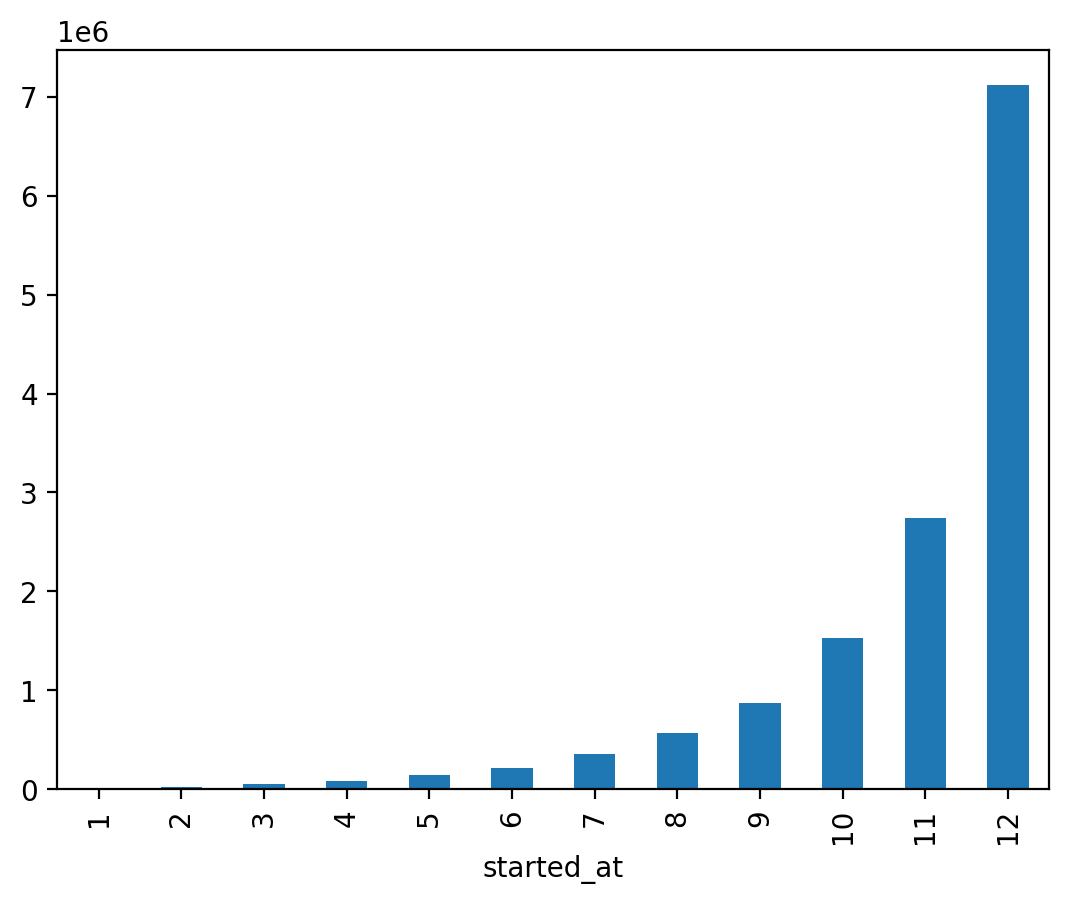

In [45]:
interactions['started_at'].dt.month.value_counts().sort_index().plot(kind='bar')

Наиболее популярные треки

In [46]:
tracks[['track_id', 'name', 'votes', 'rating']] \
    .head(10) \
    .merge(pd.DataFrame(tracks['artist'].apply(eval).explode('artist').to_list()).query('rank == 1')[['track_id', 'name']].rename(columns={'name': 'artist'}), on='track_id') \
    .merge(pd.DataFrame(tracks['album'].apply(eval).explode('album').to_list()).query('rank == 1')[['track_id', 'name']].rename(columns={'name': 'album'}), on='track_id') \
    .merge(pd.DataFrame(tracks['genre'].apply(eval).explode('genre').to_list()).query('rank == 1')[['track_id', 'name']].rename(columns={'name': 'genre'}), on='track_id') \
    .set_index([pd.Index(range(1, 11))])

,track_id,name,votes,rating,artist,album,genre
1,53404,Smells Like Teen Spirit,111062,10.00,Nirvana,Nevermind,allrock
2,33311009,Believer,106921,9.92,Imagine Dragons,Evolve,allrock
3,178529,Numb,101924,9.83,Linkin Park,Meteora,metal
4,35505245,I Got Love,99490,9.78,Miyagi & Эндшпиль,I Got Love,rap
5,65851540,Юность,86670,9.52,Dabro,Юность,pop
6,24692821,Way Down We Go,86246,9.51,KALEO,Summer Music 2016,indie
7,32947997,Shape of You,85886,9.50,Ed Sheeran,Pop,pop
8,51241318,In The End,85244,9.49,Tommee Profitt,Fall Fall Fall,rnb
9,795836,Shape Of My Heart,85042,9.48,Sting,The Best Of 25 Years,pop
10,45499814,Life,84748,9.48,Zivert,Fresh Dance,pop


Наиболее популярные жанры

In [47]:
pd.DataFrame(tracks['genre'].apply(eval).explode('genre').to_list()) \
    .drop(['track_id', 'rank'], axis=1) \
    .drop_duplicates() \
    .sort_values('votes', ascending=False) \
    .head(10) \
    .set_index([pd.Index(range(1, 11))])

,id,name,votes,rating
1,11,pop,55578305,10.00
2,75,rap,37799821,9.51
3,102,allrock,31091989,9.28
4,20,ruspop,26626234,9.09
5,3,rusrap,25303695,9.03
6,68,electronics,20120694,8.77
7,16,dance,16291557,8.53
8,2,rusrock,13166147,8.30
9,14,rock,12772620,8.27
10,47,metal,12437375,8.24


Треки, которые никто не прослушал

In [48]:
tracks[~tracks['track_id'].isin(interactions['track_id'].unique())]

,track_id,name,votes,rating,genre,album,artist,agg_genre,agg_album,agg_artist


Распределение рейтингов

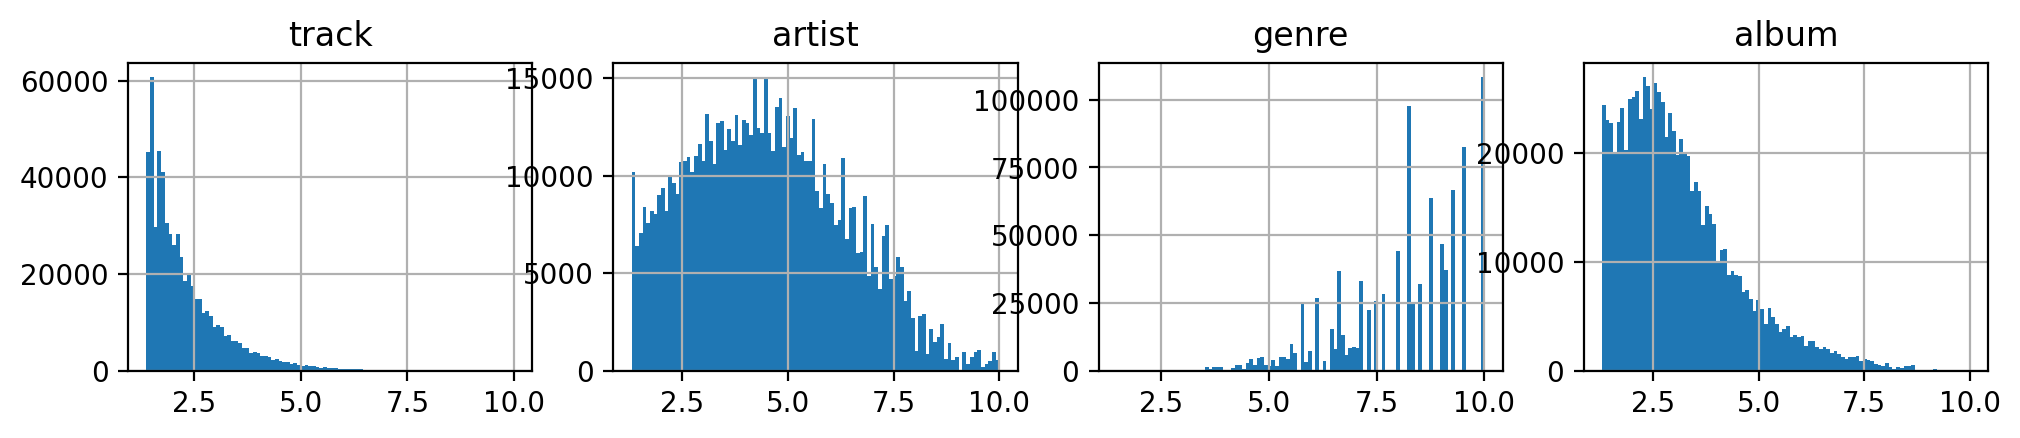

In [49]:
fig, axs = plt.subplots(nrows=1, ncols=4)
fig.set_size_inches(12, 2)

tracks['rating'].hist(bins=100, ax=axs[0])
axs[0].set_title('track')

def show_prop_rating(prop: str, ax):
    pd.DataFrame(tracks[prop].apply(eval).explode(prop).to_list())['rating'].hist(bins=100, ax=ax)
    ax.set_title(prop)

show_prop_rating('artist', axs[1])
show_prop_rating('genre', axs[2])
show_prop_rating('album', axs[3])

plt.show()

# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [50]:
tracks.rename(columns={'track_id': 'item_id'}, inplace=True)
interactions.rename(columns={'track_id': 'item_id'}, inplace=True)

tracks.to_parquet('data/items.parquet')
interactions.to_parquet('data/events.parquet')

# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [51]:
del tracks
del interactions
del catalog_names

In [52]:
import logging
import sys

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

log_file = logging.FileHandler('recommendations.log', mode='w')
log_file.setFormatter(logging.Formatter('%(asctime)s %(levelname)s %(message)s'))

console_out = logging.StreamHandler(sys.stdout)
console_out.setFormatter(logging.Formatter('%(message)s'))

logging.basicConfig(handlers=(log_file, console_out), level=logging.INFO)

# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [53]:
items = pd.read_parquet('data/items.parquet')
events = pd.read_parquet('data/events.parquet')

# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [54]:
train_split_date = pd.to_datetime('2022-12-16').to_datetime64()

train_split_date_idx = events['started_at'] < train_split_date

events_train = events[train_split_date_idx]
events_test = events[~train_split_date_idx]

events_train.shape, events_test.shape

((8983561, 8), (4703858, 8))

In [55]:
# количество пользователей в train и test
users_train = events_train['user_id'].drop_duplicates()
users_test = events_test['user_id'].drop_duplicates()
# количество пользователей, которые есть и в train, и в test
common_users = set(users_train) & set(users_test)

len(users_train), len(users_test), len(common_users)

(1063948, 782025, 473206)

# Топ популярных

Рассчитаем рекомендации как топ популярных.

# Персональные

Рассчитаем персональные рекомендации.

In [56]:
from surprise import Dataset, Reader
from surprise import SVD

# используем Reader из библиотеки surprise для преобразования событий (events)
# в формат, необходимый surprise
reader = Reader(rating_scale=(1, 10))
surprise_train_set = Dataset.load_from_df(events_train[['user_id', 'item_id', 'rating']], reader)
surprise_train_set = surprise_train_set.build_full_trainset()

# инициализируем модель
svd_model = SVD(n_factors=100, random_state=0)

# обучаем модель
svd_model.fit(surprise_train_set) 

In [57]:
surprise_test_set = list(events_test[['user_id', 'item_id', 'rating']].itertuples(index=False))

# получаем рекомендации для тестовой выборки
svd_predictions = svd_model.test(surprise_test_set) 

Анализ результатов

In [58]:
df_svd_predictions = pd.DataFrame(svd_predictions)
df_svd_predictions = df_svd_predictions.merge(items, left_on='iid', right_on='item_id', how='left')
df_svd_predictions['est2rating'] = df_svd_predictions['est'] / df_svd_predictions['rating']

In [59]:
df_svd_predictions.describe()

In [60]:
df_svd_predictions[['est', 'rating', 'est2rating']].round(3).sample(8).T

In [61]:
df_svd_predictions.query('uid == 1374582').sort_values(by='est', ascending=False)

In [62]:
df_svd_predictions[['est', 'rating', 'est2rating']].hist(bins=100, layout=(1, 3), figsize=(15, 2))

Проверка метрик на адекватность

In [63]:
from surprise import NormalPredictor
from surprise import accuracy

# инициализируем состояние генератора, это необходимо для получения
# одной и той же последовательности случайных чисел, только в учебных целях
np.random.seed(0)

random_model = NormalPredictor()

random_model.fit(surprise_train_set)
random_predictions = random_model.test(surprise_test_set)

rmse = accuracy.rmse(random_predictions)
mae = accuracy.mae(random_predictions)

In [64]:
from surprise import accuracy

rmse = accuracy.rmse(svd_predictions)
mae = accuracy.mae(svd_predictions)

In [65]:
del df_svd_predictions

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

In [66]:
import scipy
import sklearn.preprocessing

# перекодируем идентификаторы пользователей: 
# из имеющихся в последовательность 0, 1, 2, ...
user_encoder = sklearn.preprocessing.LabelEncoder()
user_encoder.fit(events['user_id'])
events_train['user_id_enc'] = user_encoder.transform(events_train['user_id'])
events_test['user_id_enc'] = user_encoder.transform(events_test['user_id'])

# перекодируем идентификаторы объектов: 
# из имеющихся в последовательность 0, 1, 2, ...
item_encoder = sklearn.preprocessing.LabelEncoder()
item_encoder.fit(items['item_id'])
items['item_id_enc'] = item_encoder.transform(items['item_id'])
events_train['item_id_enc'] = item_encoder.transform(events_train['item_id'])
events_test['item_id_enc'] = item_encoder.transform(events_test['item_id'])

/tmp/ipykernel_1940/3586575175.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_train['user_id_enc'] = user_encoder.transform(events_train['user_id'])
/tmp/ipykernel_1940/3586575175.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_test['user_id_enc'] = user_encoder.transform(events_test['user_id'])


ValueError: y contains previously unseen labels: [17684264, 32603319, 93477202, 94305274, 94305431, 94305469]

In [8]:
# создаём sparse-матрицу формата CSR 
user_item_matrix_train = scipy.sparse.csr_matrix((
    events_train['rating'],
    (events_train['user_id_enc'], events_train['item_id_enc'])),
    dtype=np.int8) 

In [9]:
from implicit.als import AlternatingLeastSquares

als_model = AlternatingLeastSquares(factors=10, iterations=10, regularization=0.05, random_state=0)
als_model.fit(user_item_matrix_train) 

/home/mle-user/mle_projects/mle-project-sprint-4-v001/env_recsys_start/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mle-user/mle_projects/mle-project-sprint-4-v001/env_recsys_start/lib/python3.10/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 4 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 10/10 [00:31<00:00,  3.13s/it]


In [10]:
user_item_matrix_train.shape, len(user_encoder.classes_)

((1160755, 39365), 1160756)

In [11]:
# получаем список всех возможных user_id (перекодированных)
user_ids_encoded = range(user_item_matrix_train.shape[0])
# user_ids_encoded = range(len(user_encoder.classes_))
# получаем рекомендации для всех пользователей
als_recommendations = als_model.recommend(
    user_ids_encoded, 
    user_item_matrix_train[user_ids_encoded], 
    filter_already_liked_items=False, N=100) 

In [12]:
# преобразуем полученные рекомендации в табличный формат
item_ids_enc = als_recommendations[0]
als_scores = als_recommendations[1]

als_recommendations = pd.DataFrame({
    'user_id_enc': user_ids_encoded,
    'item_id_enc': item_ids_enc.tolist(), 
    'score': als_scores.tolist()})
als_recommendations = als_recommendations.explode(['item_id_enc', 'score'], ignore_index=True)

# приводим типы данных
als_recommendations['item_id_enc'] = als_recommendations['item_id_enc'].astype('int')
als_recommendations['score'] = als_recommendations['score'].astype('float')

# получаем изначальные идентификаторы
als_recommendations['user_id'] = user_encoder.inverse_transform(als_recommendations['user_id_enc'])
als_recommendations['item_id'] = item_encoder.inverse_transform(als_recommendations['item_id_enc'])
als_recommendations = als_recommendations.drop(columns=['user_id_enc', 'item_id_enc']) 

In [16]:
als_recommendations.sample(8).T

,97869746,94453879,47296184,108307677,88314248,85114618,76799348,85274616
score,1.880649e-01,1.442748e-01,9.870876e-02,4.674415e-02,8.865595e-02,2.154713e-01,5.178591e-02,1.231649e-01
user_id,1.159400e+06,1.118696e+06,5.605060e+05,1.282721e+06,1.045929e+06,1.008047e+06,9.097420e+05,1.009896e+06
item_id,9.312618e+07,2.691847e+07,7.564296e+07,3.294800e+07,3.090441e+07,8.015354e+07,8.369821e+07,2.202062e+07


Анализ результатов

In [17]:
als_recommendations.shape, events_train.shape

((116075500, 3), (10303395, 10))

array([[<Axes: title={'center': 'score'}>]], dtype=object)

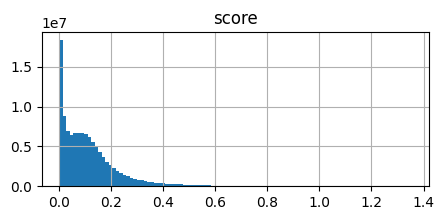

In [18]:
als_recommendations[['score']].hist(bins=100, figsize=(5, 2))

In [19]:
als_recommendations = (
    als_recommendations
    .merge(events[['user_id', 'item_id', 'rating']]
    .rename(columns={'rating': 'rating_test'}), 
    on=['user_id', 'item_id'], how='left')
) 

In [22]:
isnull_sum = als_recommendations['rating_test'].isnull().sum()
als_recommendations.shape[0], isnull_sum, als_recommendations.shape[0] - isnull_sum

(116075500, 113172448, 2903052)

In [23]:
als_recommendations.query('~rating_test.isnull()').sample(8)

,score,user_id,item_id,rating_test
46353461,0.111933,549269,93917350,5.57
84983767,0.092061,1006524,52122761,6.87
112374135,0.099484,1330715,96368212,6.08
29261513,0.267078,346740,95341975,6.21
19006607,0.201948,225161,98280795,6.73
22221100,0.847297,263311,65851540,9.52
90966066,0.162421,1077320,54014020,7.46
18536335,0.140298,219579,99668674,5.15


In [ ]:
raise ''

In [24]:
import sklearn.metrics

def compute_ndcg(rating: pd.Series, score: pd.Series, k):

    ''' подсчёт ndcg
    rating: истинные оценки
    score: оценки модели
    k: количество айтемов (по убыванию score) для оценки, остальные - отбрасываются
    '''
    
    # если кол-во объектов меньше 2, то NDCG - не определена
    if len(rating) < 2:
        return np.nan

    ndcg = sklearn.metrics.ndcg_score(np.asarray([rating.to_numpy()]), np.asarray([score.to_numpy()]), k=k)

    return ndcg 

In [25]:
ndcg_at_5_scores = als_recommendations.query('~rating_test.isnull()') \
    .groupby('user_id').apply(lambda x: compute_ndcg(x['rating_test'], x['score'], k=5)) 

In [26]:
print('NDCG@5:', ndcg_at_5_scores.mean()) 

NDCG@5: 0.9956979681678826


# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.